<a href="https://colab.research.google.com/github/raaghavkk/UG04-NLP-COMM061/blob/main/notebooks/raaghav_crossvariety.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q2.2 — Cross-Variety Evaluation
**RoBERTa fine-tuned per variety, evaluated on all varieties — Sarcasm Task**

In [1]:
!pip install transformers datasets torch scikit-learn

In [2]:
import torch
import numpy as np
import pandas as pd
from datasets import load_dataset
from transformers import RobertaTokenizer, RobertaForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [4]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset("surrey-nlp/BESSTIE-CW-26")

df_train = pd.DataFrame(ds['train'])
df_test = pd.DataFrame(ds['test'])

# Split by variety
train_au = df_train[df_train['variety'] == 'en-AU'].reset_index(drop=True)
train_in = df_train[df_train['variety'] == 'en-IN'].reset_index(drop=True)
train_uk = df_train[df_train['variety'] == 'en-UK'].reset_index(drop=True)

test_au = df_test[df_test['variety'] == 'en-AU'].reset_index(drop=True)
test_in = df_test[df_test['variety'] == 'en-IN'].reset_index(drop=True)
test_uk = df_test[df_test['variety'] == 'en-UK'].reset_index(drop=True)

print("Train sizes:", len(train_au), len(train_in), len(train_uk))
print("Test sizes:", len(test_au), len(test_in), len(test_uk))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/711k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/70.6k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/415k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3747 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/313 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2183 [00:00<?, ? examples/s]

Train sizes: 1145 1399 1203
Test sizes: 667 816 700


In [5]:
from transformers import RobertaTokenizer
from torch.utils.data import Dataset
import torch

tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

class SarcasmDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts = df['text'].tolist()
        self.labels = df['Sarcasm'].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

print("Tokenizer and dataset class ready")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer and dataset class ready


In [7]:
from transformers import RobertaForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'macro_f1': f1_score(labels, predictions, average='macro'),
        'precision': precision_score(labels, predictions, average='macro', zero_division=0),
        'recall': recall_score(labels, predictions, average='macro', zero_division=0)
    }

def train_roberta(train_df, variety_name):
    print(f"\nTraining on {variety_name}...")

    model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)

    train_dataset = SarcasmDataset(train_df, tokenizer)

    training_args = TrainingArguments(
        output_dir=f'./results_{variety_name}',
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        warmup_steps=100,
        weight_decay=0.01,
        logging_steps=50,
        save_strategy='no',
        report_to='none'
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()
    print(f"Training on {variety_name} complete!")
    return trainer, model

In [8]:
trainer_au, model_au = train_roberta(train_au, 'en-AU')


Training on en-AU...


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,0.628581
100,0.486519
150,0.525762
200,0.407082


Training on en-AU complete!


In [9]:
trainer_in, model_in = train_roberta(train_in, 'en-IN')


Training on en-IN...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,0.496016
100,0.262839
150,0.234363
200,0.231243
250,0.187578


Training on en-IN complete!


In [10]:
trainer_uk, model_uk = train_roberta(train_uk, 'en-UK')


Training on en-UK...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,0.498508
100,0.205625
150,0.228717
200,0.186863


Training on en-UK complete!


In [11]:
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

def evaluate_model(trainer, test_df, model):
    test_dataset = SarcasmDataset(test_df, tokenizer)
    predictions = trainer.predict(test_dataset)
    preds = np.argmax(predictions.predictions, axis=-1)
    labels = test_df['Sarcasm'].astype(int).tolist()

    return {
        'macro_f1': f1_score(labels, preds, average='macro'),
        'precision': precision_score(labels, preds, average='macro', zero_division=0),
        'recall': recall_score(labels, preds, average='macro', zero_division=0)
    }

# Build the 3x3 matrix
varieties = ['en-AU', 'en-IN', 'en-UK']
trainers = [trainer_au, trainer_in, trainer_uk]
models = [model_au, model_in, model_uk]
test_sets = [test_au, test_in, test_uk]

results = {}
for i, (train_variety, trainer, model) in enumerate(zip(varieties, trainers, models)):
    results[train_variety] = {}
    for j, test_variety in enumerate(varieties):
        print(f"Evaluating: trained on {train_variety}, testing on {test_variety}...")
        results[train_variety][test_variety] = evaluate_model(trainer, test_sets[j], model)

print("\nDone!")

Evaluating: trained on en-AU, testing on en-AU...


Evaluating: trained on en-AU, testing on en-IN...


Evaluating: trained on en-AU, testing on en-UK...


Evaluating: trained on en-IN, testing on en-AU...


Evaluating: trained on en-IN, testing on en-IN...


Evaluating: trained on en-IN, testing on en-UK...


Evaluating: trained on en-UK, testing on en-AU...


Evaluating: trained on en-UK, testing on en-IN...


Evaluating: trained on en-UK, testing on en-UK...



Done!



=== CROSS-VARIETY EVALUATION MATRIX (Macro-F1) ===

            Test:en-AU   Test:en-IN   Test:en-UK   
Train:en-AU   0.7101      0.5514      0.6117      
Train:en-IN   0.4241      0.5396      0.5336      
Train:en-UK   0.4193      0.5531      0.4799      


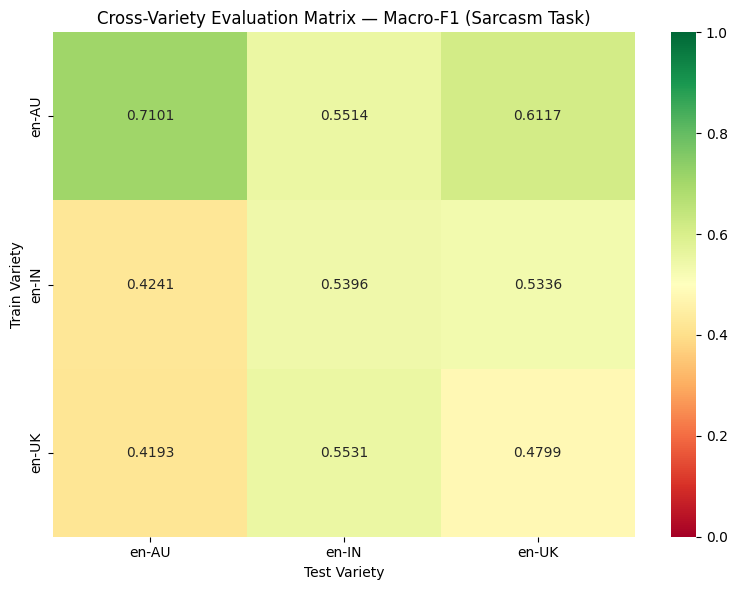

In [12]:
# Print results table
print("\n=== CROSS-VARIETY EVALUATION MATRIX (Macro-F1) ===\n")
print(f"{'':12}", end="")
for v in varieties:
    print(f"Test:{v:8}", end="")
print()

for train_v in varieties:
    print(f"Train:{train_v:8}", end="")
    for test_v in varieties:
        print(f"{results[train_v][test_v]['macro_f1']:.4f}      ", end="")
    print()

# Build F1 matrix for heatmap
f1_matrix = np.array([[results[tv][ev]['macro_f1'] for ev in varieties] for tv in varieties])

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(f1_matrix, annot=True, fmt='.4f', xticklabels=varieties, yticklabels=varieties,
            cmap='RdYlGn', vmin=0, vmax=1, ax=ax)
ax.set_xlabel('Test Variety')
ax.set_ylabel('Train Variety')
ax.set_title('Cross-Variety Evaluation Matrix — Macro-F1 (Sarcasm Task)')
plt.tight_layout()
plt.savefig('crossvariety_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
print("\n=== FULL RESULTS TABLE ===\n")
print(f"{'Train':<8} {'Test':<8} {'Macro-F1':<12} {'Precision':<12} {'Recall':<12}")
print("-" * 52)
for train_v in varieties:
    for test_v in varieties:
        r = results[train_v][test_v]
        print(f"{train_v:<8} {test_v:<8} {r['macro_f1']:<12.4f} {r['precision']:<12.4f} {r['recall']:<12.4f}")


=== FULL RESULTS TABLE ===

Train    Test     Macro-F1     Precision    Recall      
----------------------------------------------------
en-AU    en-AU    0.7101       0.7367       0.6969      
en-AU    en-IN    0.5514       0.5523       0.6361      
en-AU    en-UK    0.6117       0.5972       0.7382      
en-IN    en-AU    0.4241       0.6872       0.5040      
en-IN    en-IN    0.5396       0.6343       0.5305      
en-IN    en-UK    0.5336       0.8391       0.5275      
en-UK    en-AU    0.4193       0.8536       0.5026      
en-UK    en-IN    0.5531       0.5934       0.5417      
en-UK    en-UK    0.4799       0.4621       0.4992      


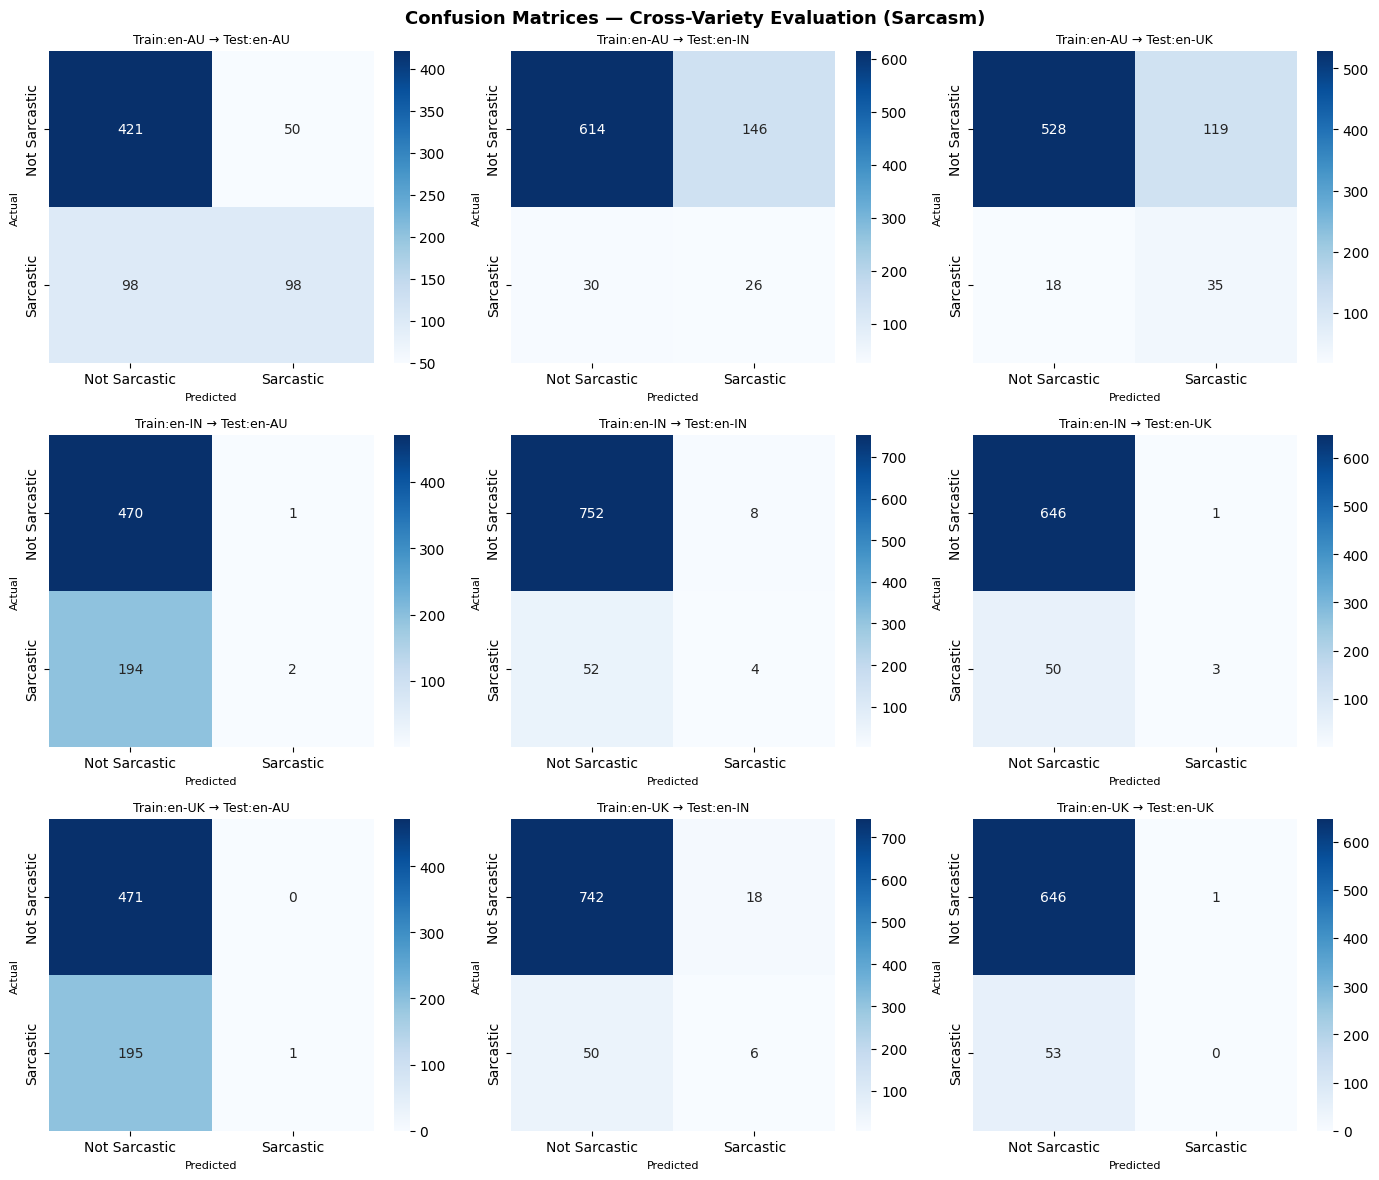

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for i, train_v in enumerate(varieties):
    for j, test_v in enumerate(varieties):
        test_dataset = SarcasmDataset(test_sets[j], tokenizer)
        predictions = trainers[i].predict(test_dataset)
        preds = np.argmax(predictions.predictions, axis=-1)
        labels = test_sets[j]['Sarcasm'].astype(int).tolist()

        cm = confusion_matrix(labels, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i][j],
                    xticklabels=['Not Sarcastic', 'Sarcastic'],
                    yticklabels=['Not Sarcastic', 'Sarcastic'])
        axes[i][j].set_title(f'Train:{train_v} → Test:{test_v}', fontsize=9)
        axes[i][j].set_xlabel('Predicted', fontsize=8)
        axes[i][j].set_ylabel('Actual', fontsize=8)

plt.suptitle('Confusion Matrices — Cross-Variety Evaluation (Sarcasm)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### Key Findings

The en-AU model is easily the most consistent performer across all conditions, like that one
person in a group project who actually does their work. It hits 0.71 on its own test set and
still manages 0.61 when tested on en-UK, which is genuinely impressive for a model that has
never seen British English during training.

The en-IN and en-UK models on the other hand are a bit of a disaster on en-AU, both dropping
to around 0.42. To put that in perspective, random chance on a binary task would give you 0.50,
so these models are actually doing worse than flipping a coin on Australian English.

Looking at the confusion matrices it becomes pretty clear why. The en-IN and en-UK models are
basically just predicting "not sarcastic" for almost everything, like that one student in an
exam who just guesses the same answer for every question. The en-UK model on its own test set
predicts literally 0 sarcastic instances, which is a complete failure for a sarcasm detection
model.

This ties directly back to the class imbalance we found in Q1. en-IN and en-UK have severe
sarcasm imbalance in the training data (around 13:1 and 11:1) so the models just learned to
ignore the minority class entirely. en-AU had a much more balanced distribution (around 2.5:1)
which is exactly why it actually learns to detect sarcasm properly.

There is also another layer to why en-IN generalises poorly. Indian English is not one
consistent variety and it varies heavily from region to region, with different vocabulary,
expressions and sarcasm patterns depending on whether someone is from Mumbai, Delhi, Chennai
or Bengal. A sarcastic comment from a Tamil speaker and one from a Punjabi speaker can look
completely different linguistically. This internal diversity makes it much harder for a model
trained on en-IN to pick up a consistent signal, compared to en-AU or en-UK which are more
regionally uniform.

A further challenge is code-mixing, which is extremely common in Indian English especially
in informal contexts like Reddit. Indian English speakers frequently use English words that
are chosen because they sound like Hindi words, carrying a completely different culturally
loaded meaning. A recent example would be using an English word as a substitute for a Hindi
slang term purely based on phonetic similarity, this kind of substitution is inherently
sarcastic and humorous in the right cultural context but looks like a completely innocent
English word to any model that lacks that cultural knowledge. RoBERTa, being pretrained on
standard English text, has no framework to interpret these phonetic substitutions, meaning
an entire layer of Indian English sarcasm is essentially invisible to it. This is a limitation
that goes beyond simple vocabulary overlap and points to a deeper cultural gap that Jaccard
similarity alone cannot capture.

The most surprising result is that en-AU trained on en-IN (0.5514) actually beats en-IN
trained on en-IN (0.5396). A model that has never seen Indian English is outperforming one
that was trained on it, which says a lot about how badly class imbalance and internal variety
diversity can hurt a model.

### Connection to Q1

These results are not surprising in isolation but become much more meaningful when read
alongside the Q1 findings. The Jaccard similarity analysis showed en-AU and en-UK share
the highest vocabulary overlap (0.3345), which explains why the en-AU model transfers
reasonably well to en-UK. The heavy sarcasm class imbalance in en-IN and en-UK training
sets directly explains why those models collapse into majority class prediction. The
code-mixing and regional diversity in en-IN adds a further dimension that simple overlap
metrics cannot capture. Together these findings suggest that for sarcasm detection,
data balance matters more than linguistic proximity when it comes to cross-variety transfer.

## Q2.2 — Cross-Variety Evaluation (Sarcasm Task)

For this experiment we fine-tuned RoBERTa-base three times, once on each variety's training
set, then evaluated every model against all three test sets to build a full 3x3 cross-variety
evaluation matrix. The goal was to understand how well a model trained on one variety of
English transfers to another.

### Experimental Setup

Model: roberta-base
Task: Sarcasm Detection (binary classification)
Training: 3 epochs, batch size 16, warmup steps 100, weight decay 0.01
Each model was trained exclusively on one variety and never saw the other two during training.

### Results

| Train \ Test | en-AU  | en-IN  | en-UK  |
|-------------|--------|--------|--------|
| en-AU       | 0.7101 | 0.5514 | 0.6117 |
| en-IN       | 0.4241 | 0.5396 | 0.5336 |
| en-UK       | 0.4193 | 0.5531 | 0.4799 |

Full precision and recall breakdown:

| Train | Test  | Macro-F1 | Precision | Recall |
|-------|-------|----------|-----------|--------|
| en-AU | en-AU | 0.7101   | 0.7367    | 0.6969 |
| en-AU | en-IN | 0.5514   | 0.5523    | 0.6361 |
| en-AU | en-UK | 0.6117   | 0.5972    | 0.7382 |
| en-IN | en-AU | 0.4241   | 0.6872    | 0.5040 |
| en-IN | en-IN | 0.5396   | 0.6343    | 0.5305 |
| en-IN | en-UK | 0.5336   | 0.8391    | 0.5275 |
| en-UK | en-AU | 0.4193   | 0.8536    | 0.5026 |
| en-UK | en-IN | 0.5531   | 0.5934    | 0.5417 |
| en-UK | en-UK | 0.4799   | 0.4621    | 0.4992 |